<a href="https://colab.research.google.com/github/LUKASZCOM/LICENCJAT/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Dane czyste




In [ ]:
## Import bibliotek
import matplotlib.pyplot as plt
import numpy as np
import time
import tensorflow as tf
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
## Wgranie zbioru CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
class_name = ['Samolot', 'Samochód', 'Ptak', 'Kot', 'Jeleń',
               'Pies', 'Żaba', 'Koń', 'Statek', 'Ciężarówka']

## Tworzenie architektury CNN
def cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5 ),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
## Tworzenie naszego modelu CNN
model = cnn_model()
model.summary()
start_time = time.time()
cnn_clean = model.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

In [ ]:
results = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss = results[0]
global_acc = results[1]
print(global_acc)
print(global_loss)

0.7631999850273132
1.046972632408142


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (Clean CNN)
training_accuracy = cnn_clean.history['accuracy']
training_loss = cnn_clean.history['loss']
validation_accuracy = cnn_clean.history['val_accuracy']
validation_loss = cnn_clean.history['val_loss']

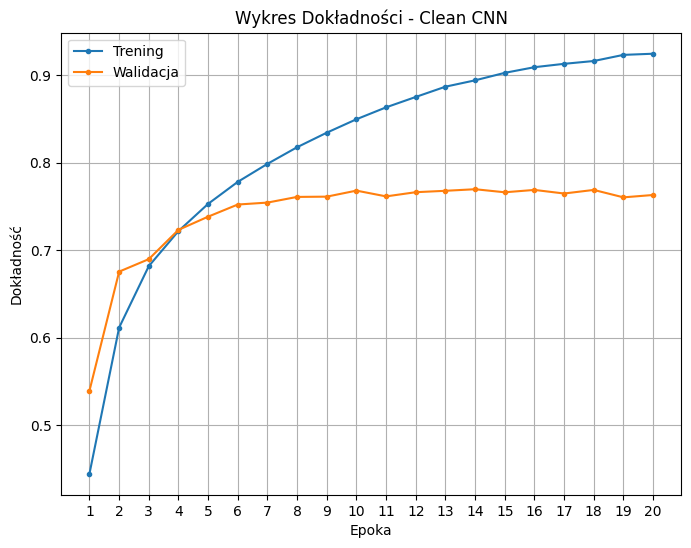

In [ ]:
## Wykres dokładnośći (Clean CNN)
epochs_num = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num, training_accuracy, label='Trening', marker='.')
plt.plot(epochs_num, validation_accuracy, label='Walidacja', marker='.')

plt.title('Wykres Dokładności - Clean CNN')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num)
plt.legend()
plt.grid(True)

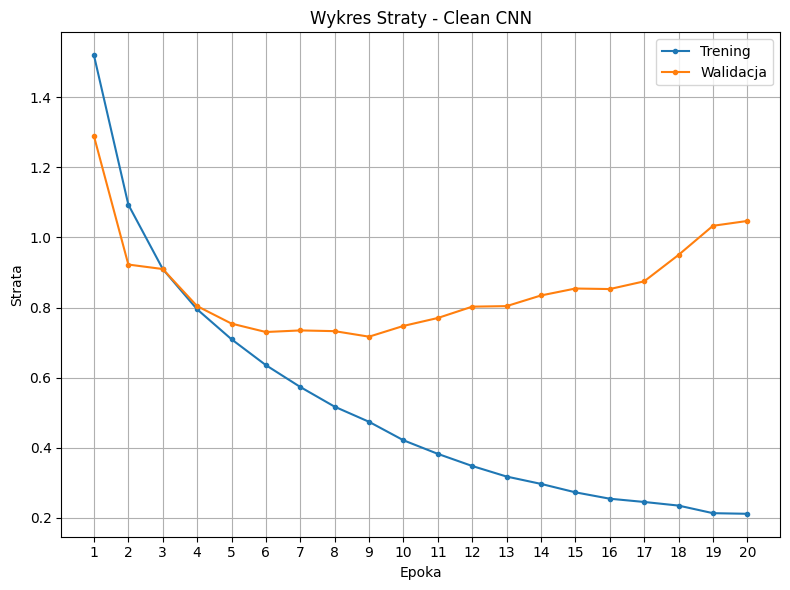

In [ ]:
## Wykres straty (Clean CNN)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num, training_loss, label='Trening', marker='.')
plt.plot(epochs_num, validation_loss, label='Walidacja', marker='.')

plt.title('Wykres Straty - Clean CNN')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- RAPORT SZCZEGÓŁOWY - Clean CNN ---
              precision    recall  f1-score   support

     Samolot       0.82      0.78      0.80      1000
    Samochód       0.86      0.90      0.88      1000
        Ptak       0.65      0.69      0.67      1000
         Kot       0.60      0.60      0.60      1000
       Jeleń       0.76      0.65      0.70      1000
        Pies       0.64      0.75      0.69      1000
        Żaba       0.86      0.75      0.80      1000
         Koń       0.79      0.82      0.81      1000
      Statek       0.86      0.84      0.85      1000
  Ciężarówka       0.82      0.86      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



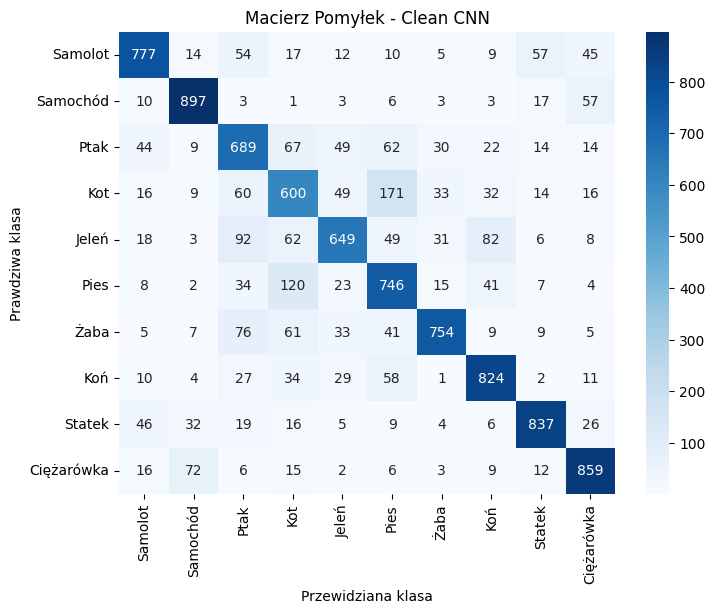

In [ ]:


y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - Clean CNN ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - Clean CNN')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()


# Label flipping



In [ ]:
def poison_label(y_train_cat, ratio):
    y_pois_label = np.copy(y_train_cat)
    labels = np.argmax(y_train_cat, axis=1)

    for a, b in [(1,9), (3,5)]:
        for c, d in [(a,b), (b,a)]:
            indx = np.where(labels == c)[0]
            wybor = np.random.choice(indx, int(len(indx) * ratio), replace=False)
            y_pois_label[wybor, :] = 0
            y_pois_label[wybor, d] = 1
    return y_pois_label

## 10%

In [ ]:
## Tworzenie naszego modelu CNN
y_train_poisoned_10 = poison_label(y_train_cat, ratio=0.1)
model = cnn_model()
model.summary()
start_time = time.time()
cnn_10 = model.fit(
    x_train, y_train_poisoned_10,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4470 - loss: 1.5067 - val_accuracy: 0.5825 - val_loss: 1.1700
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6063 - loss: 1.0985 - val_accuracy: 0.6527 - val_loss: 0.9649
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6710 - loss: 0.9244 - val_accuracy: 0.6969 - val_loss: 0.8658
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7124 - loss: 0.8124 - val_accuracy: 0.7074 - val_loss: 0.8248
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7375 - loss: 0.7400 - val_accuracy: 0.7482 - val_loss: 0.7504
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7622 - loss: 0.6637 - val_accuracy: 0.7528 - val_loss: 0.7270
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7851 - loss: 0.5983 - val_accuracy: 0.7529 - val_loss: 0.7427
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8013 - loss: 0.5454 - val_accuracy: 

In [ ]:
results_10 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_10 = results_10[0]
global_acc_10 = results_10[1]
print(global_acc_10)
print(global_loss_10)

0.7455999851226807
1.0280386209487915


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (MLP 10%)
training_accuracy_10 = cnn_10.history['accuracy']
training_loss_10 = cnn_10.history['loss']
validation_accuracy_10 = cnn_10.history['val_accuracy']
validation_loss_10 = cnn_10.history['val_loss']

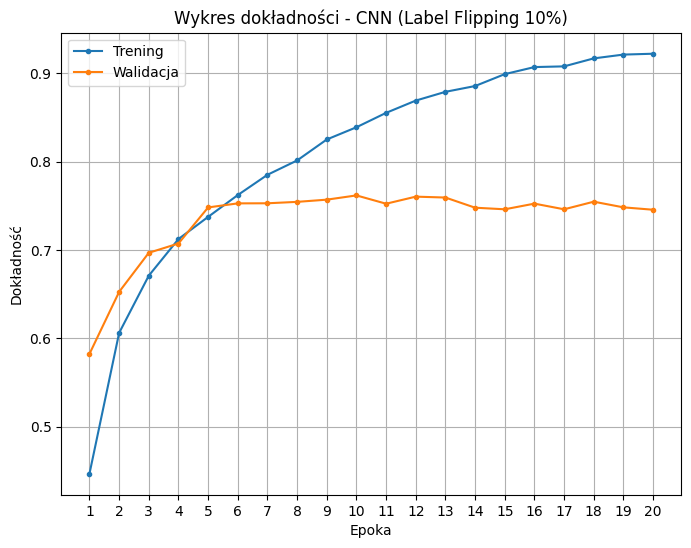

In [ ]:
## Wykres dokładności (CNN 10%)
epochs_num_10 = range(1, len(training_accuracy_10) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num_10, training_accuracy_10, label='Trening', marker='.')
plt.plot(epochs_num_10, validation_accuracy_10, label='Walidacja', marker='.')

plt.title('Wykres dokładności - CNN (Label Flipping 10%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num_10)
plt.legend()
plt.grid(True)

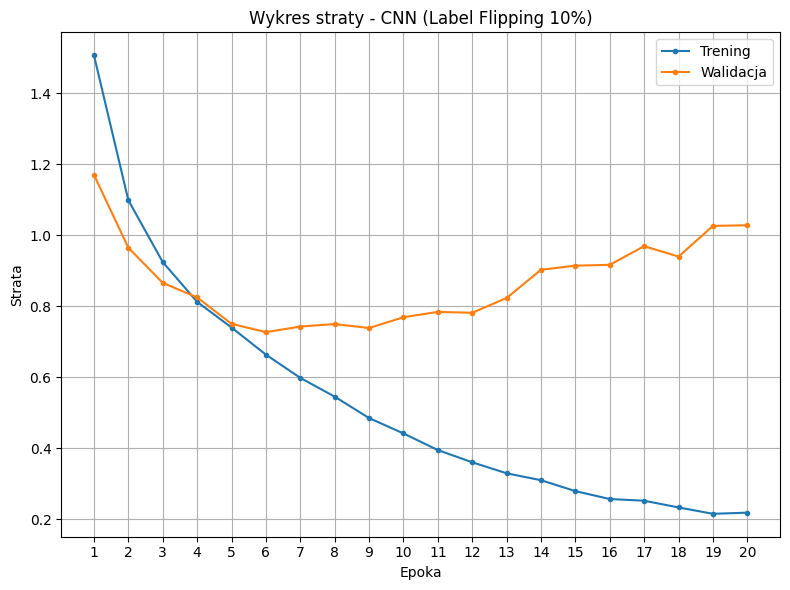

In [ ]:
## Wykres straty (MLP 10%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_10, training_loss_10, label='Trening', marker='.')
plt.plot(epochs_num_10, validation_loss_10, label='Walidacja', marker='.')


plt.title('Wykres straty - CNN (Label Flipping 10%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num_10)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

--- RAPORT SZCZEGÓŁOWY - CNN (Label Flipping 10%) ---
              precision    recall  f1-score   support

     Samolot       0.75      0.83      0.79      1000
    Samochód       0.77      0.88      0.82      1000
        Ptak       0.67      0.66      0.67      1000
         Kot       0.57      0.56      0.56      1000
       Jeleń       0.80      0.63      0.71      1000
        Pies       0.67      0.63      0.65      1000
        Żaba       0.77      0.82      0.79      1000
         Koń       0.82      0.81      0.82      1000
      Statek       0.85      0.86      0.85      1000
  Ciężarówka       0.77      0.78      0.78      1000

    accuracy                           0.75     10000
   macro avg       0.74      0.75      0.74     10000
weighted avg       0.74      0.75      0.74     10000



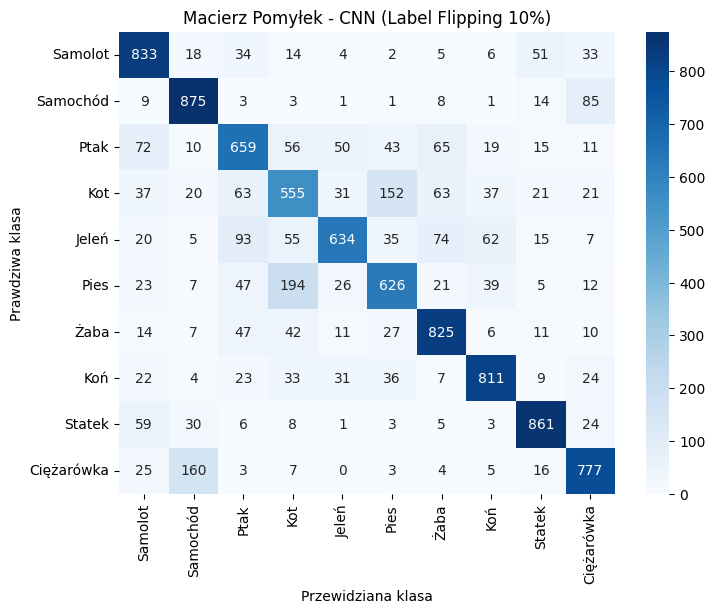

In [ ]:
## Macierz pomyłek i raport szczegółowy
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - CNN (Label Flipping 10%) ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - CNN (Label Flipping 10%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 20%

In [ ]:
## Tworzenie naszego modelu CNN
y_train_poisoned_20 = poison_label(y_train_cat, ratio=0.2)
model = cnn_model()
model.summary()
start_time = time.time()
cnn_20 = model.fit(
    x_train, y_train_poisoned_20,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4284 - loss: 1.5323 - val_accuracy: 0.5724 - val_loss: 1.1666
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5790 - loss: 1.1352 - val_accuracy: 0.6637 - val_loss: 0.9601
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6389 - loss: 0.9739 - val_accuracy: 0.6946 - val_loss: 0.8872
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6724 - loss: 0.8716 - val_accuracy: 0.7023 - val_loss: 0.8701
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7045 - loss: 0.7865 - val_accuracy: 0.7375 - val_loss: 0.7797
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7284 - loss: 0.7176 - val_accuracy: 0.7390 - val_loss: 0.7712
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7508 - loss: 0.6547 - val_accuracy: 0.7449 - val_loss: 0.7569
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7683 - loss: 0.6016 - val_accuracy: 

In [ ]:
results_20 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_20 = results_20[0]
global_acc_20 = results_20[1]
print(global_acc_20)
print(global_loss_20)

0.7297000288963318
1.0889099836349487


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (CNN 20%)
training_accuracy_20 = cnn_20.history['accuracy']
training_loss_20 = cnn_20.history['loss']
validation_accuracy_20 = cnn_20.history['val_accuracy']
validation_loss_20 = cnn_20.history['val_loss']

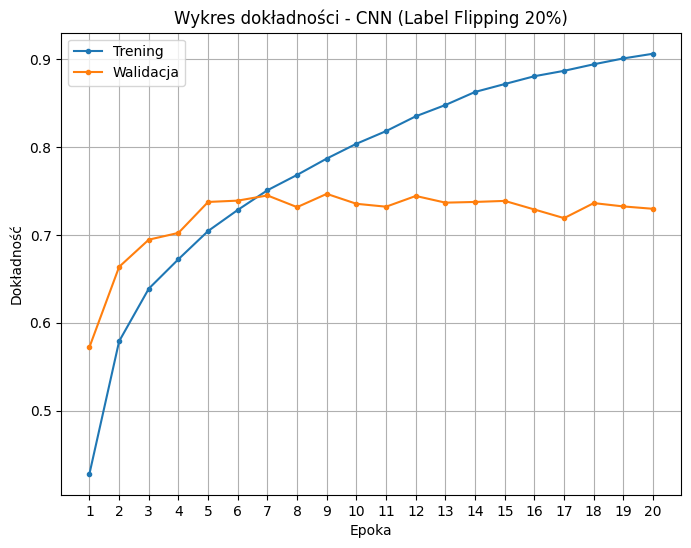

In [ ]:
## Wykres dokładności (CNN 20%)
epochs_num_20 = range(1, len(training_accuracy_20) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num_20, training_accuracy_20, label='Trening', marker='.')
plt.plot(epochs_num_20, validation_accuracy_20, label='Walidacja', marker='.')

plt.title('Wykres dokładności - CNN (Label Flipping 20%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num_20)
plt.legend()
plt.grid(True)

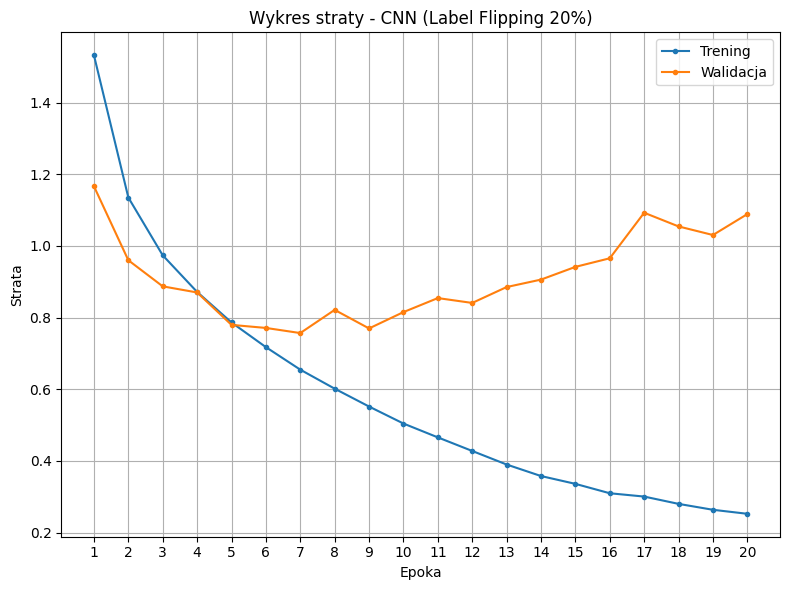

In [ ]:
## Wykres straty (CNN 20%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_20, training_loss_20, label='Trening', marker='.')
plt.plot(epochs_num_20, validation_loss_20, label='Walidacja', marker='.')


plt.title('Wykres straty - CNN (Label Flipping 20%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num_20)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

--- RAPORT SZCZEGÓŁOWY - CNN (Label Flipping 20%) ---
              precision    recall  f1-score   support

     Samolot       0.78      0.82      0.80      1000
    Samochód       0.77      0.80      0.78      1000
        Ptak       0.62      0.69      0.65      1000
         Kot       0.53      0.47      0.50      1000
       Jeleń       0.68      0.75      0.71      1000
        Pies       0.66      0.51      0.58      1000
        Żaba       0.79      0.82      0.81      1000
         Koń       0.81      0.81      0.81      1000
      Statek       0.84      0.87      0.86      1000
  Ciężarówka       0.78      0.75      0.77      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



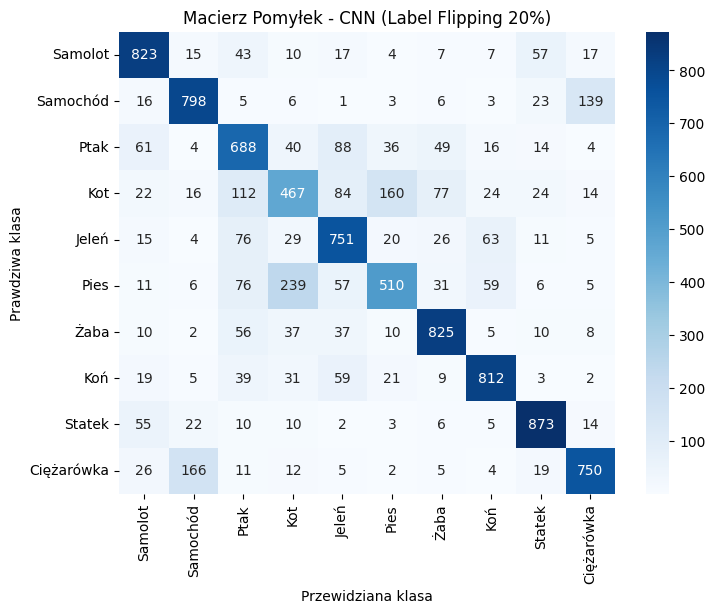

In [ ]:
## Macierz pomyłek i raport szczegółowy
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - CNN (Label Flipping 20%) ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - CNN (Label Flipping 20%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()

## 30%

In [ ]:
## Tworzenie naszego modelu CNN
y_train_poisoned_30 = poison_label(y_train_cat, ratio=0.3)
model = cnn_model()
model.summary()
start_time = time.time()
cnn_30 = model.fit(
    x_train, y_train_poisoned_30,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test_cat),
    verbose=1
)
end_time = time.time()
duration = end_time - start_time
print(f"Czas = {duration}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4068 - loss: 1.5710 - val_accuracy: 0.5312 - val_loss: 1.2574
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5518 - loss: 1.1707 - val_accuracy: 0.6355 - val_loss: 1.0274
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6129 - loss: 0.9996 - val_accuracy: 0.6844 - val_loss: 0.9166
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6481 - loss: 0.8934 - val_accuracy: 0.6853 - val_loss: 0.8974
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6762 - loss: 0.8138 - val_accuracy: 0.6985 - val_loss: 0.8529
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6992 - loss: 0.7516 - val_accuracy: 0.7210 - val_loss: 0.8096
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7182 - loss: 0.6938 - val_accuracy: 0.7273 - val_loss: 0.8187
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7359 - loss: 0.6458 - val_accuracy: 

In [ ]:
results_30 = model.evaluate(x_test, y_test_cat, verbose=0)
global_loss_30 = results_30[0]
global_acc_30 = results_30[1]
print(global_acc_30)
print(global_loss_30)

0.7020999789237976
1.2183971405029297


In [ ]:
## Wyciągnięcie parametrów potrzebnych do naszych wykresów (CNN 30%)
training_accuracy_30 = cnn_30.history['accuracy']
training_loss_30 = cnn_30.history['loss']
validation_accuracy_30 = cnn_30.history['val_accuracy']
validation_loss_30 = cnn_30.history['val_loss']

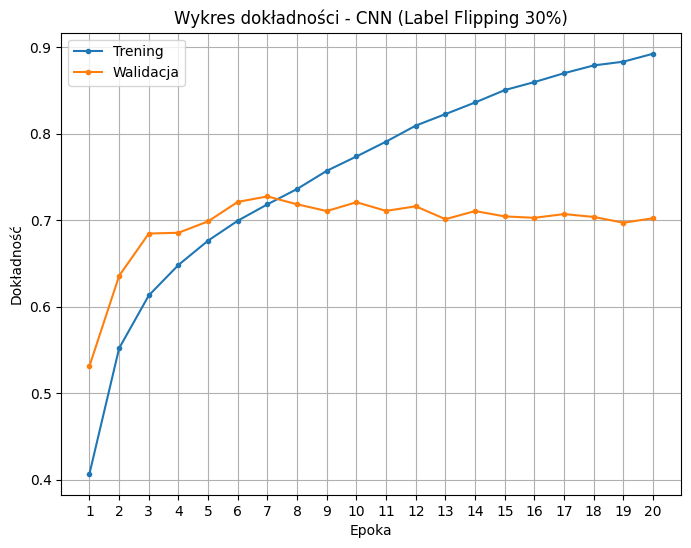

In [ ]:
## Wykres dokładności (CNN 30%)
epochs_num_30 = range(1, len(training_accuracy_30) + 1)
plt.figure(figsize=(8, 6))

plt.plot(epochs_num_30, training_accuracy_30, label='Trening', marker='.')
plt.plot(epochs_num_30, validation_accuracy_30, label='Walidacja', marker='.')

plt.title('Wykres dokładności - CNN (Label Flipping 30%)')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')

plt.xticks(epochs_num_30)
plt.legend()
plt.grid(True)

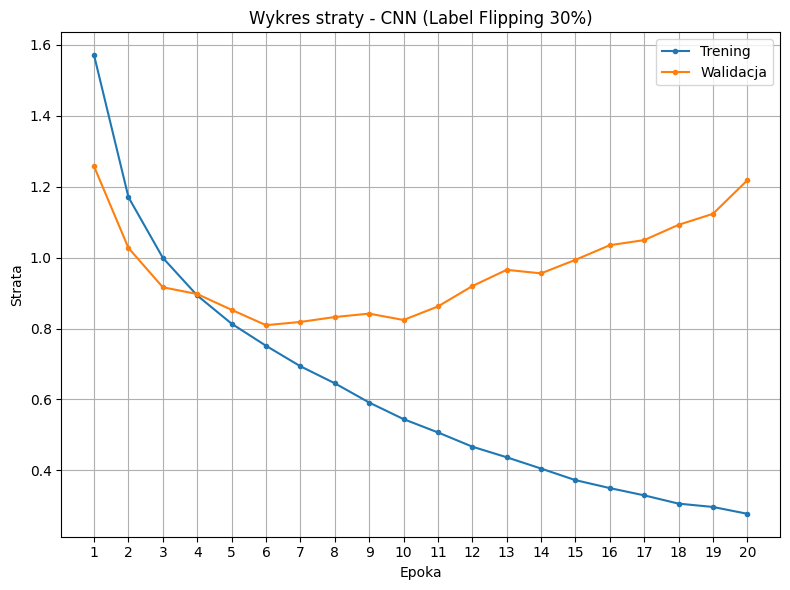

In [ ]:
## Wykres straty (CNN 30%)
plt.figure(figsize=(8, 6))
plt.plot(epochs_num_30, training_loss_30, label='Trening', marker='.')
plt.plot(epochs_num_30, validation_loss_30, label='Walidacja', marker='.')


plt.title('Wykres straty - CNN (Label Flipping 30%)')
plt.xlabel('Epoka')
plt.ylabel('Strata')
plt.xticks(epochs_num_30)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- RAPORT SZCZEGÓŁOWY - CNN (Label Flipping 30%) ---
              precision    recall  f1-score   support

     Samolot       0.79      0.80      0.79      1000
    Samochód       0.71      0.66      0.68      1000
        Ptak       0.66      0.70      0.68      1000
         Kot       0.47      0.46      0.47      1000
       Jeleń       0.70      0.76      0.73      1000
        Pies       0.58      0.42      0.49      1000
        Żaba       0.85      0.78      0.81      1000
         Koń       0.78      0.84      0.81      1000
      Statek       0.79      0.90      0.84      1000
  Ciężarówka       0.65      0.70      0.68      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



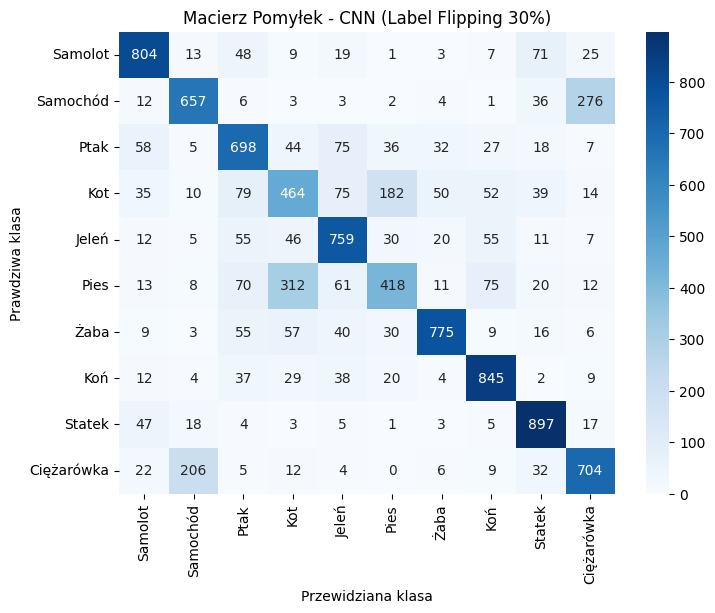

In [ ]:
## Macierz pomyłek i raport szczegółowy
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

print("\n--- RAPORT SZCZEGÓŁOWY - CNN (Label Flipping 30%) ---")
print(classification_report(y_true, y_pred, target_names=class_name))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_name, yticklabels=class_name)
plt.title('Macierz Pomyłek - CNN (Label Flipping 30%)')
plt.ylabel('Prawdziwa klasa')
plt.xlabel('Przewidziana klasa')
plt.show()